      services        date             time ride_status  \
0  cab economy  2024-07-15  08:30:40.542646   completed   
1         auto  2024-07-05  23:36:51.542646   completed   
2         auto  2024-07-23  11:05:37.542646   cancelled   
3  cab economy  2024-06-24  08:45:10.542646   completed   
4  cab economy  2024-07-15  00:26:44.542646   completed   

                   source               destination  duration  \
0         Balagere Harbor           Harohalli Nagar        39   
1  Basavanagudi 3rd Block      Bikasipura 1st Stage        89   
2        Babusapalya Cove         Kothaguda Terrace        25   
3       Mahadevapura Mews            Kanakapura Arc        89   
4         Ganganagar Cove  Basaveshwaranagar Colony        95   

              ride_id  distance  ride_charge  misc_charge  total_fare  \
0  RD3161218751875354     27.21       764.83        31.51      796.34   
1  RD8171514284594096     34.03       314.83        49.52      364.35   
2  RD9376481122237926     20.24    

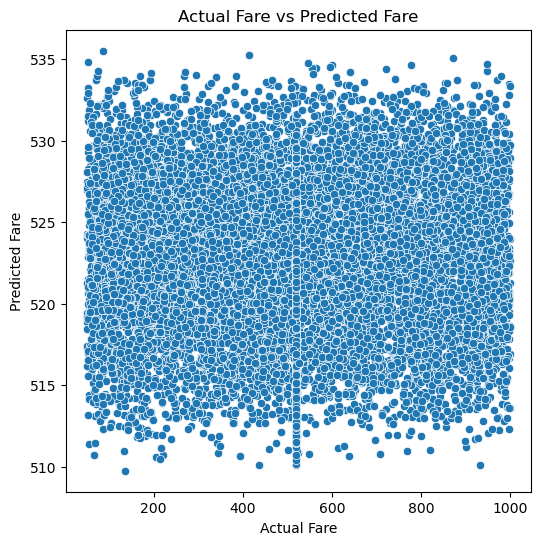

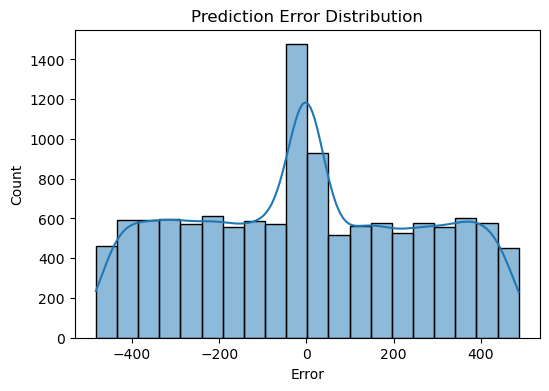


Model and scaler saved successfully as 'fare_model.pkl' and 'fare_scaler.pkl'!


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
df = pd.read_csv("rides_data.csv")   
print(df.head())
cols = ["distance", "duration", "ride_charge", "misc_charge", "total_fare"]
for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())
service_encoder = LabelEncoder()
payment_encoder = LabelEncoder()
payment_encoder.fit([
    "Amazon Pay",
    "Paytm",
    "QR scan",
    "Cash",
    "Card",
    "UPI"
])
service_encoder.fit(["cab economy", "auto", "bike", "bike lite", "parcel"])
df["services"] = df["services"].astype("category").cat.codes
df["source"] = df["source"].astype("category").cat.codes
df["destination"] = df["destination"].astype("category").cat.codes
df["payment_method"] = df["payment_method"].astype("category").cat.codes
df["ride_status"] = df["ride_status"].astype("category").cat.codes
X = df[["distance", "duration", "services", "payment_method"]]
y = df["ride_charge"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nMean Absolute Error :", round(mean_absolute_error(y_test, y_pred), 2))
print("Mean Squared Error  :", round(mean_squared_error(y_test, y_pred), 2))
print("R2 Score            :", round(r2_score(y_test, y_pred), 2))
result = pd.DataFrame({
    "Actual Fare": y_test,
    "Predicted Fare": y_pred
})
print("\nFirst 5 Predictions")
print(result.head())
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual Fare vs Predicted Fare")
plt.show()
errors = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(errors, bins=20, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()
joblib.dump(service_encoder, "service_encoder.pkl")
joblib.dump(payment_encoder, "payment_encoder.pkl")
joblib.dump(model, "fare_model.pkl")
joblib.dump(scaler, "fare_scaler.pkl")
print("\nModel and scaler saved successfully as 'fare_model.pkl' and 'fare_scaler.pkl'!")

In [36]:
%%writefile taxifare_app.py
import streamlit as st
import numpy as np
import joblib
model = joblib.load("fare_model.pkl")
scaler = joblib.load("fare_scaler.pkl")
service_encoder = joblib.load("service_encoder.pkl")
payment_encoder = joblib.load("payment_encoder.pkl")
st.set_page_config(
    page_title="FareSense - Smart Taxi Fare Predictor",
    page_icon="🚕",
    layout="centered",
    initial_sidebar_state="expanded",
)
st.markdown(""" 
    <style> 
        .title { 
            text-align: center; 
            font-size: 38px; 
            color: #2A7AE2; 
            font-weight: 800; 
            margin-bottom: 5px; 
        } 
        .subtitle { 
            text-align: center; 
            font-size: 18px; 
            color: #4B4B4B; 
            margin-bottom: 30px; 
        } 
        .stButton>button { 
            width: 100%; 
            background-color: #2A7AE2; 
            color: white; 
            font-size: 18px; 
            padding: 12px; 
            border-radius: 10px; 
        } 
        .stButton>button:hover { 
            background-color: #1F5BB5; 
            color: white; 
        } 
        .card { 
            padding: 20px; 
            border-radius: 15px; 
            background-color: #F0F6FF; 
            box-shadow: 1px 1px 10px #d1d1d1; 
        } 
        .footer { 
            text-align: center; 
            color: #888888; 
            font-size: 14px; 
            margin-top: 30px; 
        } 
    </style> 
""", unsafe_allow_html=True) 

 
st.markdown('<div class="title">🚕 FareSense</div>', unsafe_allow_html=True) 
st.markdown('<div class="subtitle">Smart Taxi Fare Predictor</div>', unsafe_allow_html=True) 
 
st.markdown('<div class="card">', unsafe_allow_html=True) 
 
col1, col2 = st.columns(2) 
with col1: 
    distance = st.number_input("Distance (km)", 0.0, 100.0, step=0.5) 
    service = st.selectbox("Service Type", list(service_encoder.classes_)) 
with col2: 
    duration = st.number_input("Duration (minutes)", 0, 200, step=1) 
    payment = st.selectbox("Payment Method", list(payment_encoder.classes_)) 
 
st.markdown('</div>', unsafe_allow_html=True) 
st.write("") 
 
predict_btn = st.button("Predict Fare") 
 
if predict_btn: 
    service_enc = service_encoder.transform([service])[0] 
    payment_enc = payment_encoder.transform([payment])[0] 
 
    input_data = np.array([[distance, duration, service_enc, payment_enc]]) 
    input_scaled = scaler.transform(input_data) 
    predicted_fare = model.predict(input_scaled)[0] 
    predicted_fare = max(predicted_fare, 0)  # fares can't be negative 
 
    st.success(f"Estimated fare: **₹{predicted_fare:.2f}**") 
 
st.write("---") 
st.markdown( 
    "<p class='footer'>© 2026 FareSense - All Rights Reserved.</p>", 
    unsafe_allow_html=True, 
)

Overwriting taxifare_app.py


In [37]:
!streamlit run taxifare_app.py

^C
